# Column transformation
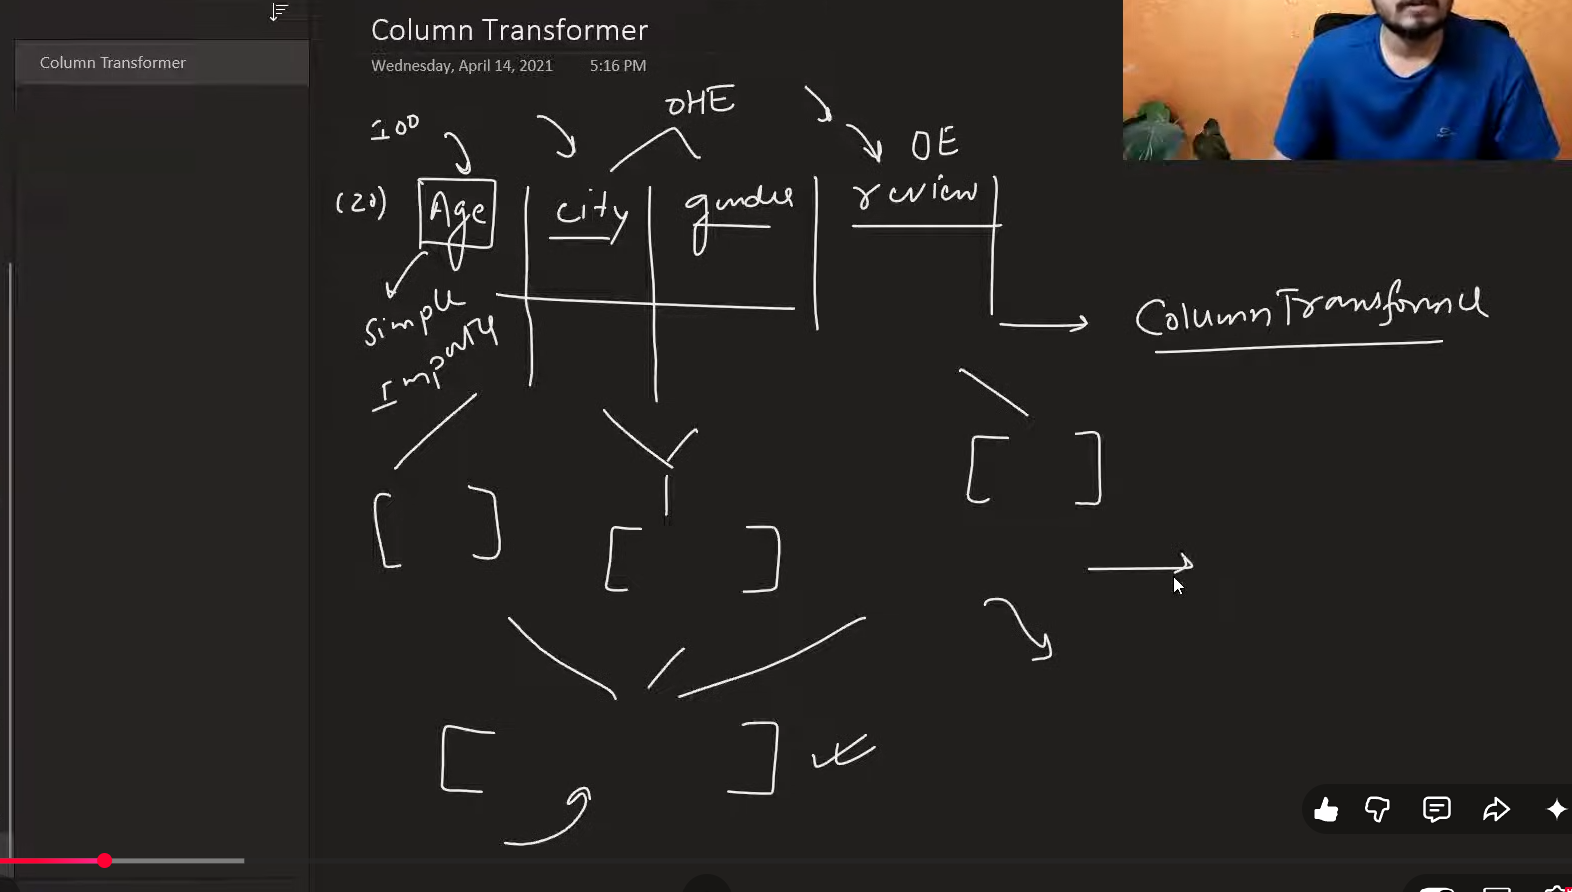

summary 
All column may have different different issues so handling them together is very tricky 
ex = if u have 5 columns on which ordianal , OneHotEncoding etc is being used so after implementation u will 
get multiple numpy arrays then u will have to combine it in and then get 1 numpy array . 
this is very hactic work if u have many columns. 


so column transformation do this thing in just single code this makes our work very easy 

In [27]:
import numpy as np
import pandas as pd

url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day28-column-transformer/covid_toy.csv"
df = pd.read_csv(url)

In [5]:
df.head(5)

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [9]:
from sklearn .model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns = ['has_covid']),df['has_covid'],test_size = 0.2)

In [14]:
x_train

,age,gender,fever,cough,city
27,33,Female,102.0,Strong,Delhi
72,83,Female,101.0,Mild,Kolkata
6,14,Male,101.0,Strong,Bangalore
79,48,Female,103.0,Mild,Kolkata
32,34,Female,101.0,Strong,Delhi
...,...,...,...,...,...
39,50,Female,103.0,Mild,Kolkata
13,64,Male,102.0,Mild,Bangalore
45,72,Male,99.0,Mild,Bangalore
0,60,Male,103.0,Mild,Kolkata


# Aam jindagi

In [15]:
# adding simple imputer to fever col
from sklearn.impute import SimpleImputer
si = SimpleImputer()
x_train_fever = si.fit_transform(x_train[['fever']])

# also the test data
x_test_fever = si.fit_transform(x_test[['fever']])

x_train_fever.shape

(80, 1)

In [31]:
# Ordinalencoding -> cough
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['Mild', 'Strong']])
x_train_cough = oe.fit_transform(x_train[['cough']])

# also the test data
x_test_cough = oe.fit_transform(x_test[['cough']])

x_train_cough.shape

(80, 1)

In [23]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output = False)
x_train_gender_city = ohe.fit_transform(x_train[['gender', 'city']])

# also the test data
x_test_gender_city = ohe.fit_transform(x_test[['gender', 'city']])

x_train_gender_city.shape

(80, 4)

In [25]:
# Extracting Age
x_train_age = x_train.drop(columns=['gender', 'fever', 'cough', 'city']).values

# also the test data
x_test_age = x_test.drop(columns=['gender', 'fever', 'cough', 'city']).values

x_train_age.shape

(80, 1)

In [32]:
x_train_transformed = np.concatenate((x_train_age, x_train_fever, x_train_gender_city, x_train_cough), axis=1)
# also the test data
x_test_transformed = np.concatenate((x_test_age, x_test_fever, x_test_gender_city, x_test_cough), axis=1)

x_train_transformed.shape

(80, 7)

# Mentos jindagi

In [46]:
from sklearn.compose import ColumnTransformer
transformer = ColumnTransformer(transformers = [
    ('tnfi',SimpleImputer(),['fever']),
    ('tnf2',OrdinalEncoder(categories = [['Mild','Strong']]),['cough']),
    ('tnf3', OneHotEncoder(sparse_output = False,drop = 'first'),['gender','city'])
    ],remainder = 'passthrough')

In [47]:
transformer.fit_transform(x_train).shape

(80, 7)

In [48]:
transformer.transform(x_test).shape

(20, 7)

# Summary

Instead of manually doing this:

Creating an imputer, fitting it, and transforming the fever column.

Creating an ordinal encoder, fitting it, and transforming the cough column.

Creating a one-hot encoder, fitting it, and transforming the city/gender columns.

Manually using np.concatenate to glue all those separate pieces back together.

You can just put all three steps inside ColumnTransformer under different step names (like your 'tnfi', 'tnf2', and 'tnf3'). It runs all the libraries together at the exact same time, automatically handles the alignment, combines the columns for you, and gives you the exact same final output array.

It makes your code much cleaner and prevents bugs when you start processing your test data.